In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from pathlib import Path
from src.features import preprocess_trip_data, convert_to_datetime, extract_datetime_features, create_rush_hour_feature, calculate_manhattan_distance, calculate_haversine_distance
from src.train import train_model
from src.models import get_random_forest_model, get_xgboost_model, get_gbr_model, get_lgbm_model, get_catboost_model
from src.predictor import predictor
from src.model_tuning import objective
import src.plots as plots

In [2]:
# Define file paths
base_path = Path.cwd()
parent_path = base_path.parent
train_path = parent_path / 'data' / 'raw' / 'train.csv'
test_path = parent_path / 'data' / 'raw' / 'test.csv'

In [3]:
# Load train and test data
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

### Exploratory Data Analysis

In [4]:
# Train data information
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [5]:
# Train data exploration
print("Train data shape:", train_data.shape)
print("Train data sample:")
train_data.sample(3)

Train data shape: (1458644, 11)
Train data sample:


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
722457,id3497035,2,2016-02-05 10:38:19,2016-02-05 10:49:47,1,-73.971558,40.760609,-73.982887,40.766930,N,688
593375,id3799971,2,2016-02-09 13:50:43,2016-02-09 14:06:14,1,-73.993477,40.727509,-73.980927,40.750488,N,931
740185,id1994661,2,2016-01-14 14:39:31,2016-01-14 14:47:54,6,-73.959152,40.783115,-73.977127,40.787823,N,503


In [6]:
print("Missing values in train data: {}".format(train_data.isnull().sum().sum()))
print("Duplicated rows in train data: {}".format(train_data.duplicated().sum()))
print("Duplicated IDs in train data: {}".format(train_data["id"].duplicated().sum()))

Missing values in train data: 0
Duplicated rows in train data: 0
Duplicated IDs in train data: 0


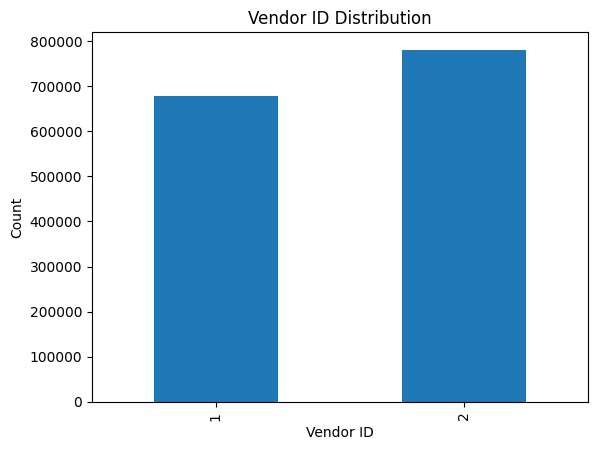

In [7]:
# Vendor distribution plot
plots.plot_vendor_distribution(train_data)

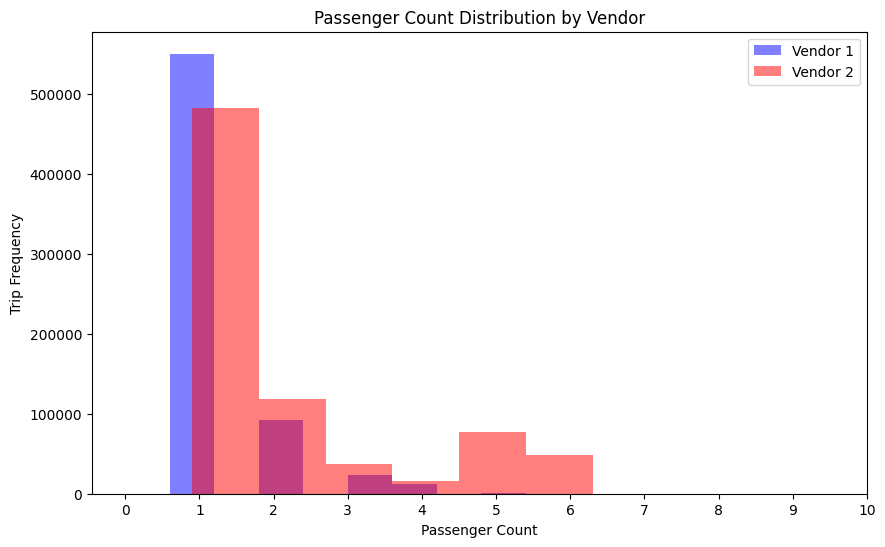

Total passenger count distribution:
passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64


In [8]:
# Passenger count distribution plot
plots.plot_passenger_count_distribution(train_data)
print("Total passenger count distribution:")
print(train_data["passenger_count"].value_counts().sort_index())

Zero passengers or more than seven might indicate a canceled trip or a data entry error.

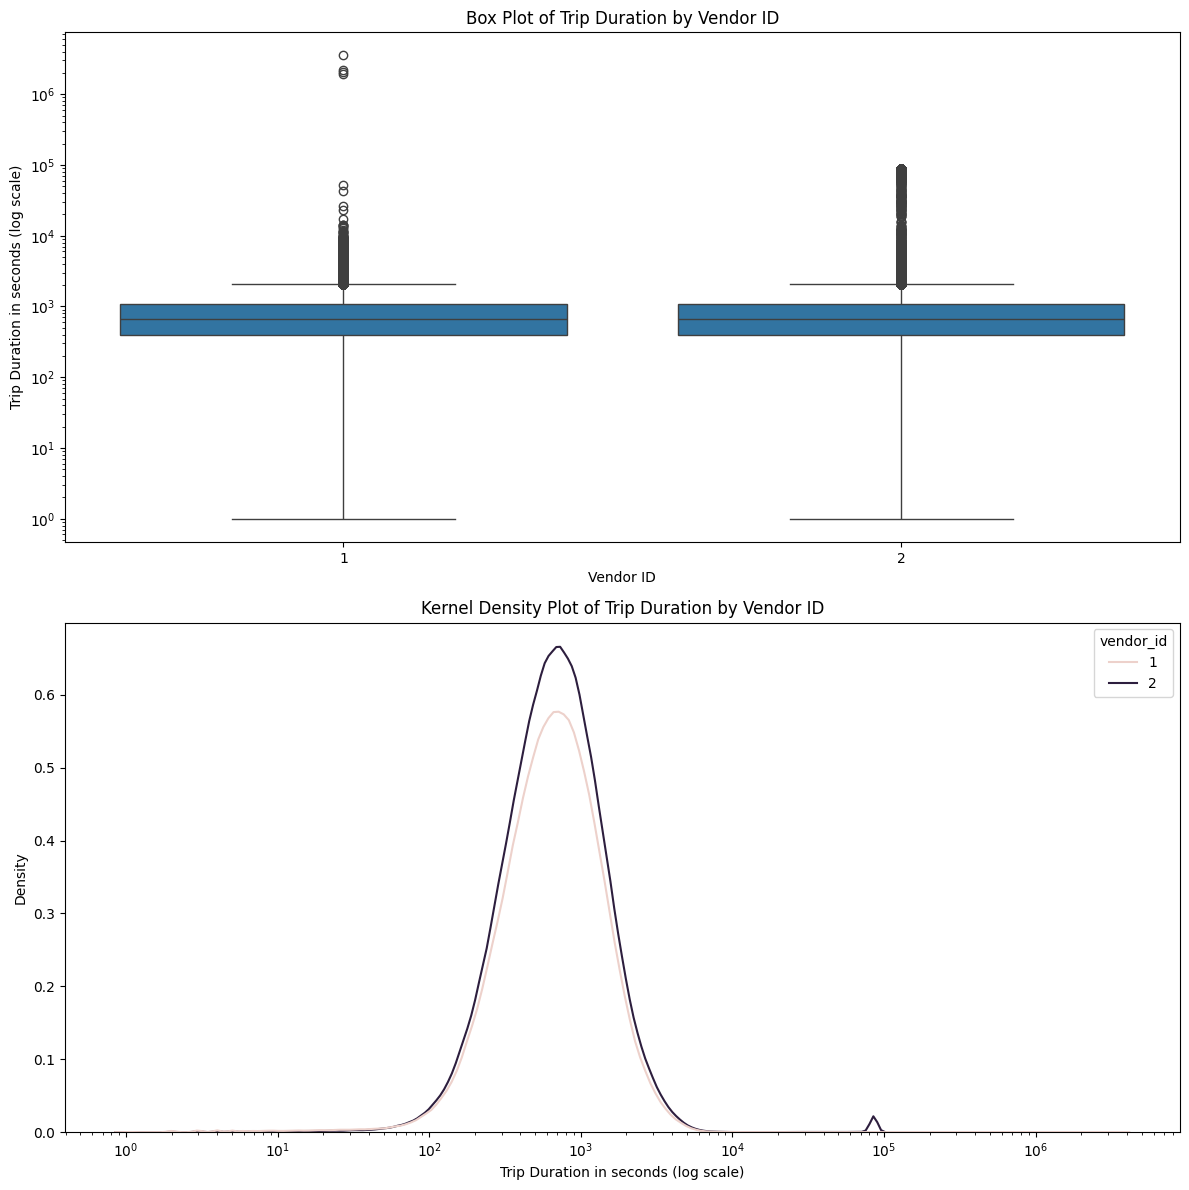

In [9]:
# Trip duration distribution plot
plots.plot_trip_duration_distribution(train_data)

Outliers might indicate technical errors (meters left running), extreme traffic/events or operational anomalies (cancelled rides that still record a pickup/dropoff).

In [10]:
# Explore trip duration statistics
train_data["trip_duration"].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

Dataset is extremely "bottom-heavy." With a median (50th percentile) of 662 but a maximum of 3,526,282.

The Floor: A taxi ride of 1 (unit) is likely a technical error or an immediate cancellation.

The Ceiling: A value of 3.5 million (40 days) is almost certainly a meter left running or a GPS glitch.

### Feature engineering

In [11]:
# Remove outliers based on trip duration (e.g., trips longer than 2 hours or shorter than 1 minute) and remove rows with zero passengers
train_data_clean = preprocess_trip_data(train_data)
print("Train data after cleaning rows", train_data_clean.shape)

Train data after cleaning rows (1447597, 11)


In [12]:
# Convert pickup_datetime to datetime, extract features, and create rush hour feature
train_data_clean = convert_to_datetime(train_data_clean)
train_data_clean = extract_datetime_features(train_data_clean)
train_data_clean = create_rush_hour_feature(train_data_clean)

train_data_clean.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,rush_hour
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,1
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,1
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,0


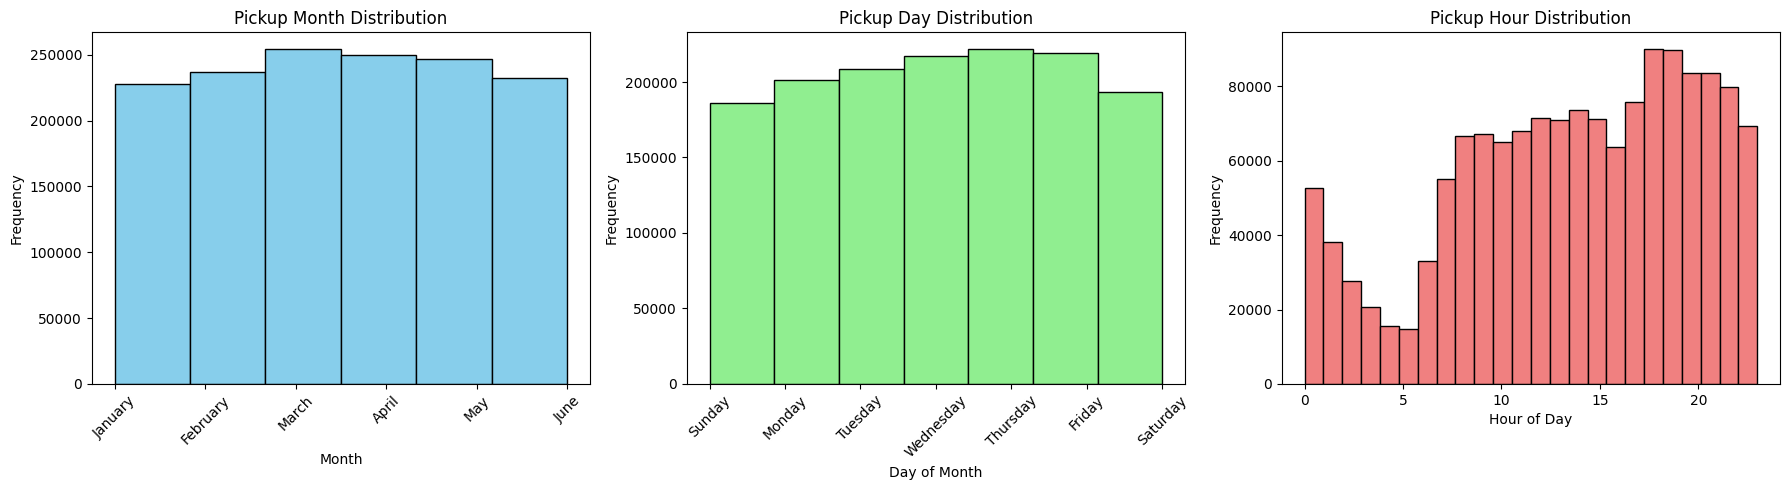

In [ ]:
# Visualize the distribution of pickup month, day, and hour
plots.plot_pickup_time_distribution(train_data_clean)

In [18]:
# Createte distance features using the Manhattan and Haversine distance functions
train_data_clean["manhattan_distance"] = calculate_manhattan_distance(train_data_clean["pickup_latitude"], 
                                                                      train_data_clean["pickup_longitude"], 
                                                                      train_data_clean["dropoff_latitude"], 
                                                                      train_data_clean["dropoff_longitude"]
                                                                      )

train_data_clean["haversine_distance"] = calculate_haversine_distance(train_data_clean["pickup_latitude"], 
                                                                      train_data_clean["pickup_longitude"],
                                                                      train_data_clean["dropoff_latitude"], 
                                                                      train_data_clean["dropoff_longitude"]
                                                                      )

In [16]:
# Display the first few rows of the cleaned and feature-engineered training data
train_data_clean.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,rush_hour,manhattan_distance,haversine_distance
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,1,0.019859,0.026154
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,0,0.026478,0.031512
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0,0.080158,0.111441
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,1,0.015480,0.025927
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,0,0.010818,0.020745


### Feature sets

In [17]:
# Prepare the data for modeling
BASE_FEATURES = ["vendor_id", 
                 "pickup_hour", 
                 "pickup_day", 
                 "pickup_month", 
                 "passenger_count", 
                 "pickup_longitude", 
                 "pickup_latitude", 
                 "dropoff_longitude", 
                 "dropoff_latitude"]

ENGINEERED_FEATURES = BASE_FEATURES + ["manhattan_distance", 
                                       "haversine_distance", 
                                       "rush_hour"]

### Train models and track results

In [ ]:
# Train models and evaluate performance
best_result = []
best_score = float('inf')

results = []

experiments = [
    {"name": "RF_base", "factory": get_random_forest_model, "features": BASE_FEATURES},
    {"name": "XGB_base", "factory": get_xgboost_model, "features": BASE_FEATURES},
    {"name": "GBR_base", "factory": get_gbr_model, "features": BASE_FEATURES},
    {"name": "LGBM_base", "factory": get_lgbm_model, "features": BASE_FEATURES},
    {"name": "Cat_base", "factory": get_catboost_model, "features": BASE_FEATURES},
    {"name": "Cat_engineered", "factory": get_catboost_model, "features": ENGINEERED_FEATURES},
    {"name": "XGB_engineered", "factory": get_xgboost_model, "features": ENGINEERED_FEATURES},
    {"name": "GBR_engineered", "factory": get_gbr_model, "features": ENGINEERED_FEATURES},
    {"name": "LGBM_engineered", "factory": get_lgbm_model, "features": ENGINEERED_FEATURES},
    {"name": "RF_engineered", "factory": get_random_forest_model, "features": ENGINEERED_FEATURES}
]

for exp in experiments:
    model = exp["factory"]()
    score = train_model(model, exp["features"], train_data_clean)

    results.append({
        "name": exp["name"],
        "model": model,
        "features": exp["features"],
        "score": score
    })

    if score < best_score:
        best_score = score
        best_result = exp

    print(f"Experiment: {exp['name']}, Features: {exp['features']}, RMSLE: {score:.4f}")

### Compare results

In [ ]:
# Display all results sorted by score
results_df = pd.DataFrame(results).sort_values("score")
results_df

In [ ]:
print(f"Best Model: {best_result['name']}, Features: {best_result['features']}, RMSLE: {best_score:.4f}")

### Predict on test set

In [ ]:
# Predict on test set

test_data_clean = convert_to_datetime(test_data)
test_data_clean = extract_datetime_features(test_data_clean)

Y_pred_test = predictor(best_result["factory"](), train_data_clean, test_data_clean, BASE_FEATURES)
print("Five predictions:", Y_pred_test[:5])

### Optimize best model

In [ ]:
# Hyperparameter tuning with Optuna
study = optuna.create_study(direction='minimize')

study.optimize(
    lambda trial: objective(trial, factory=best_result["factory"], features=best_result["features"], train_data=train_data_clean),
    n_trials=50,
    show_progress_bar=True
    )